# Traffic Sign Recognition from Object Detection Dataset

This notebook demonstrates a professional approach to building a Traffic Sign Recognition (Classification) Deep Learning model. 

**Key Features:**
1. **Data Parsing**: The given dataset is formatted for Object Detection (YOLO). We write a custom pipeline to read bounding boxes, extract the traffic signs, and formulate a classification dataset.
2. **Preprocessing**: Resizing crops to 32x32, normalizing, and employing Data Augmentation.
3. **Model Choice**: Convolutional Neural Networks (CNNs) implementing Dropout layers for regularization.
4. **Experimentation**: Comparing models trained with **ReLU** vs **ELU** activation functions.
5. **Professional Training**: Utilizing `EarlyStopping` and `ReduceLROnPlateau` for optimal convergence.
6. **Comprehensive Evaluation**: Metrics including Accuracy, Precision, Recall, F1-Score, and Visual Confusion Matrix.


## 1. Import Essential Libraries


In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.20.0


## 2. Dataset Setup & YOLO Parsing

The local data is in `Traffic_sign_detection_data`. Let's process the YOLO labels (`.txt`), which have format:
`class_id x_center y_center width height` (all normalized). We'll un-normalize these, crop the traffic signs exactly, and resize them to `(32x32)`.


In [2]:
# Define exact paths for the localized dataset
dataset_path = 'd:/plymouth ai project/Traffic_sign_detection_data'

images_train_path = os.path.join(dataset_path, 'images', 'train')
labels_train_path = os.path.join(dataset_path, 'labels', 'train')
images_val_path = os.path.join(dataset_path, 'images', 'val')
labels_val_path = os.path.join(dataset_path, 'labels', 'val')

# Image properties
IMG_HEIGHT = 32
IMG_WIDTH = 32
CHANNELS = 3
NUM_CLASSES = 43

def extract_yolo_crops(images_dir, labels_dir, desc="Loading data"):
    X, y = [], []
    if not os.path.exists(images_dir) or not os.path.exists(labels_dir):
        print(f"Error: Path {images_dir} or {labels_dir} not found!")
        return np.array(X), np.array(y)
        
    img_files = [f for f in os.listdir(images_dir) if f.endswith('.jpg')]
    
    for img_name in tqdm(img_files, desc=desc):
        img_path = os.path.join(images_dir, img_name)
        label_name = img_name.replace('.jpg', '.txt')
        label_path = os.path.join(labels_dir, label_name)
        
        if not os.path.exists(label_path):
            continue
            
        try:
            # Open Original Image
            image = Image.open(img_path).convert('RGB')
            img_w, img_h = image.size
            
            # Open YOLO annotation values
            with open(label_path, 'r') as f:
                lines = f.readlines()
                
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(float(parts[0]))
                    x_c_n, y_c_n, w_n, h_n = map(float, parts[1:5])
                    
                    # Convert normalized coords to absolute pixel values
                    w = int(w_n * img_w)
                    h = int(h_n * img_h)
                    x_c = int(x_c_n * img_w)
                    y_c = int(y_c_n * img_h)
                    
                    # Compute box boundaries
                    left = max(0, x_c - w // 2)
                    upper = max(0, y_c - h // 2)
                    right = min(img_w, x_c + w // 2)
                    lower = min(img_h, y_c + h // 2)
                    
                    # Ensure valid bounding box crop
                    if right > left and lower > upper:
                        sign_crop = image.crop((left, upper, right, lower))
                        sign_crop = sign_crop.resize((IMG_WIDTH, IMG_HEIGHT))
                        
                        X.append(np.array(sign_crop))
                        y.append(class_id)
        except Exception as e:
            pass # Skips any unreadable files

    return np.array(X), np.array(y)

# Extract images for Training and Validation logic
X_train_full, y_train_full = extract_yolo_crops(images_train_path, labels_train_path, desc="Parsing Train Set")
X_val_all, y_val_all = extract_yolo_crops(images_val_path, labels_val_path, desc="Parsing Validation Set")

print(f"Loaded {len(X_train_full)} training items.")
print(f"Loaded {len(X_val_all)} validation items.")


Parsing Train Set:   0%|          | 0/7643 [00:00<?, ?it/s]

Parsing Validation Set:   0%|          | 0/1891 [00:00<?, ?it/s]

Loaded 17843 training items.
Loaded 4297 validation items.


### Displaying Extracted Crops
Let's ensure the bounding boxes correctly cropped the traffic signs.


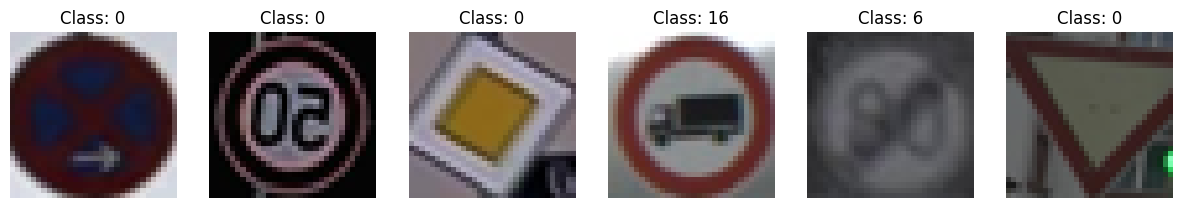

In [3]:
# Display a few random training crops
if len(X_train_full) > 0:
    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    for i in range(6):
        idx = random.randint(0, len(X_train_full) - 1)
        axes[i].imshow(X_train_full[idx])
        axes[i].set_title(f"Class: {y_train_full[idx]}")
        axes[i].axis('off')
    plt.show()


### Normalization & Structured Dataset Splits

We will normalize pixels to `[0, 1]`, and one-hot encode all targets. Then, since the provided data only has `train` and `val` directories, we will split the YOLO `val` into two halves to create a dedicated **Test Set**.


In [4]:
# Normalize data
X_train_full = X_train_full / 255.0
X_val_all = X_val_all / 255.0

# Encode labels
y_train_cat = to_categorical(y_train_full, NUM_CLASSES)
y_val_all_cat = to_categorical(y_val_all, NUM_CLASSES)

# Split the original validation set equally to form Validation and Proper Test Sets
X_val, X_test, y_val, y_test = train_test_split(X_val_all, y_val_all_cat, test_size=0.5, random_state=42, shuffle=True)

print("--- Final Dataset Shapes ---")
print(f"X_train : {X_train_full.shape} 	 y_train : {y_train_cat.shape}")
print(f"X_val   : {X_val.shape} 	 y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape} 	 y_test  : {y_test.shape}")


--- Final Dataset Shapes ---
X_train : (17843, 32, 32, 3) 	 y_train : (17843, 43)
X_val   : (2148, 32, 32, 3) 	 y_val   : (2148, 43)
X_test  : (2149, 32, 32, 3) 	 y_test  : (2149, 43)


### Advanced Data Augmentation
We employ an `ImageDataGenerator` configured specifically for traffic contexts (minor angular tilts, translations).


In [5]:
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(X_train_full)


## 3. Designing the Models (ReLU vs ELU)

We design a professional CNN layout ensuring spatial invariance with Pooling and strong regularization with Dropout layers to prevent overfitting on the minor variations.


In [6]:
def create_cnn(activation_function='relu'):
    model = Sequential([
        # Block 1
        Conv2D(32, (3, 3), padding='same', activation=activation_function, input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)),
        Conv2D(32, (3, 3), activation=activation_function),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.2),
        
        # Block 2
        Conv2D(64, (3, 3), padding='same', activation=activation_function),
        Conv2D(64, (3, 3), activation=activation_function),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.3),
        
        # Output Block
        Flatten(),
        Dense(256, activation=activation_function),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_relu = create_cnn('relu')
model_elu = create_cnn('elu')

print("CNN Architectures successfully constructed!")


c:\Users\wifi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Architectures successfully constructed!


## 4. Professional Training Setup
Using EarlyStopping dynamically halts training when `val_loss` plateaus. Using ReduceLROnPlateau drops the learning rate when stuck in local minima to squeeze out ultimate precision.


In [7]:
EPOCHS = 40
BATCH_SIZE = 64

callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1)
]

print("\n[1] === Training CNN with ReLU ===")
history_relu = model_relu.fit(
    datagen.flow(X_train_full, y_train_cat, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks_list,
    verbose=1
)

print("\n[2] === Training CNN with ELU ===")
history_elu = model_elu.fit(
    datagen.flow(X_train_full, y_train_cat, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks_list,
    verbose=1
)



[1] === Training CNN with ReLU ===
Epoch 1/40
279/279 ━━━━━━━━━━━━━━━━━━━━ 32s 103ms/step - accuracy: 0.7711 - loss: 1.2116 - val_accuracy: 0.7486 - val_loss: 1.2167 - learning_rate: 0.0010
Epoch 2/40
279/279 ━━━━━━━━━━━━━━━━━━━━ 28s 99ms/step - accuracy: 0.7730 - loss: 0.9526 - val_accuracy: 0.7514 - val_loss: 0.8720 - learning_rate: 0.0010
Epoch 3/40
279/279 ━━━━━━━━━━━━━━━━━━━━ 28s 100ms/step - accuracy: 0.7791 - loss: 0.8032 - val_accuracy: 0.7784 - val_loss: 0.7356 - learning_rate: 0.0010
Epoch 4/40
279/279 ━━━━━━━━━━━━━━━━━━━━ 28s 101ms/step - accuracy: 0.7945 - loss: 0.7076 - val_accuracy: 0.7877 - val_loss: 0.6322 - learning_rate: 0.0010
Epoch 5/40
279/279 ━━━━━━━━━━━━━━━━━━━━ 28s 99ms/step - accuracy: 0.8104 - loss: 0.6286 - val_accuracy: 0.8268 - val_loss: 0.5139 - learning_rate: 0.0010
Epoch 6/40
279/279 ━━━━━━━━━━━━━━━━━━━━ 28s 100ms/step - accuracy: 0.8208 - loss: 0.5733 - val_accuracy: 0.8371 - val_loss: 0.4692 - learning_rate: 0.0010
Epoch 7/40
279/279 ━━━━━━━━━━━━━━━━━

## 5. Visual Evaluation of Learning Curves

We track the trajectory of convergence to ensure models are neither heavily biased nor overfitting.


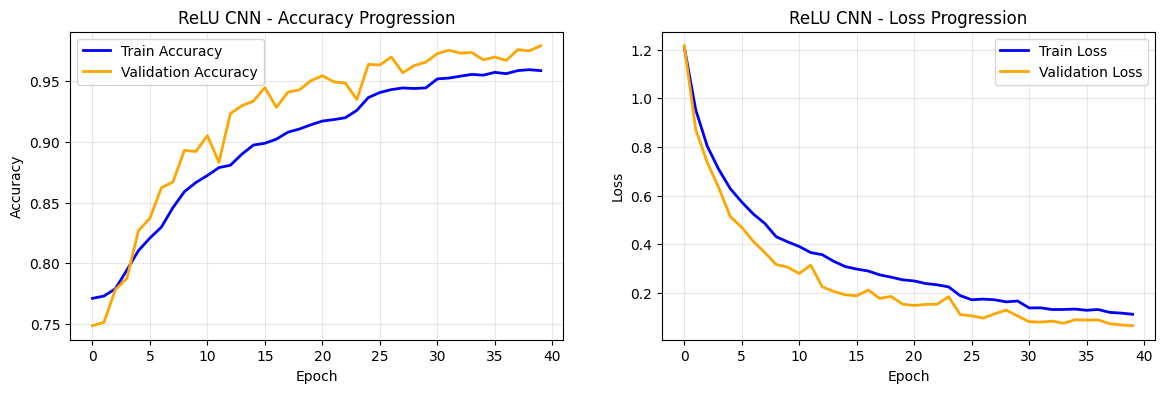

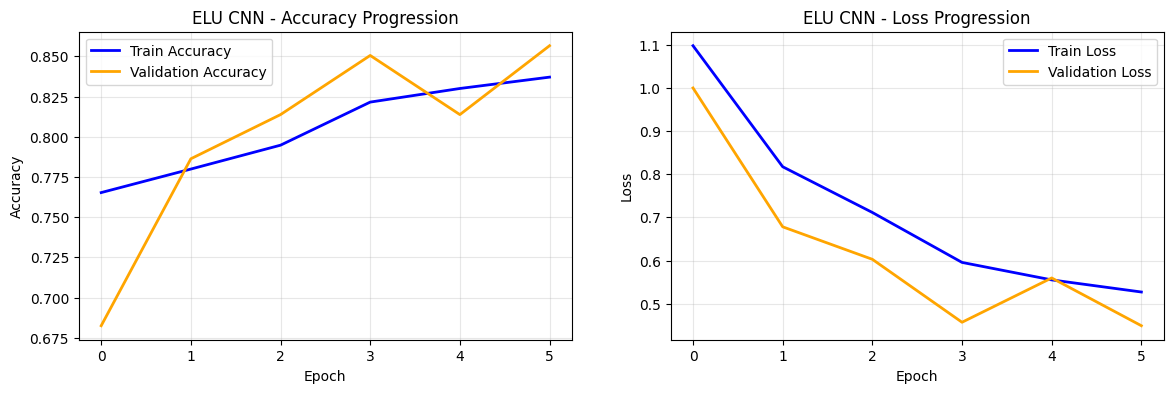

In [8]:
def plot_training_curves(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Accuracy Curve
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue', lw=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', lw=2)
    axes[0].set_title(f'{name} - Accuracy Progression')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].grid(alpha=0.3)
    axes[0].legend()
    
    # Loss Curve
    axes[1].plot(history.history['loss'], label='Train Loss', color='blue', lw=2)
    axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange', lw=2)
    axes[1].set_title(f'{name} - Loss Progression')
    axes[1].set_ylabel('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].grid(alpha=0.3)
    axes[1].legend()
    
    plt.show()

plot_training_curves(history_relu, "ReLU CNN")
plot_training_curves(history_elu, "ELU CNN")


## 6. Comprehensive Testing via Critical Metrics
Let's expose both networks strictly to the completely unseen **Test Set**.


In [9]:
y_test_true = np.argmax(y_test, axis=1)

def measure_model(model, title):
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Calculation across weighted classes natively maps multi-class stability
    precision = precision_score(y_test_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_true, y_pred, average='weighted', zero_division=0)
    
    print(f"\n--- {title} Test Metrics ---")
    print(f"Accuracy  : {accuracy * 100:.2f}%")
    print(f"Precision : {precision * 100:.2f}%")
    print(f"Recall    : {recall * 100:.2f}%")
    print(f"F1-Score  : {f1 * 100:.2f}%")
    return y_pred

print("Evaluating generalization on strictly unseen Test items...")
pred_relu = measure_model(model_relu, "ReLU Architecture")
pred_elu = measure_model(model_elu, "ELU Architecture")


Evaluating generalization on strictly unseen Test items...

--- ReLU Architecture Test Metrics ---
Accuracy  : 97.25%
Precision : 97.11%
Recall    : 97.25%
F1-Score  : 97.13%

--- ELU Architecture Test Metrics ---
Accuracy  : 69.10%
Precision : 73.37%
Recall    : 69.10%
F1-Score  : 69.82%


### Confusion Matrix Analysis
Visualizing exactly where the model might be getting confused among differing signs.


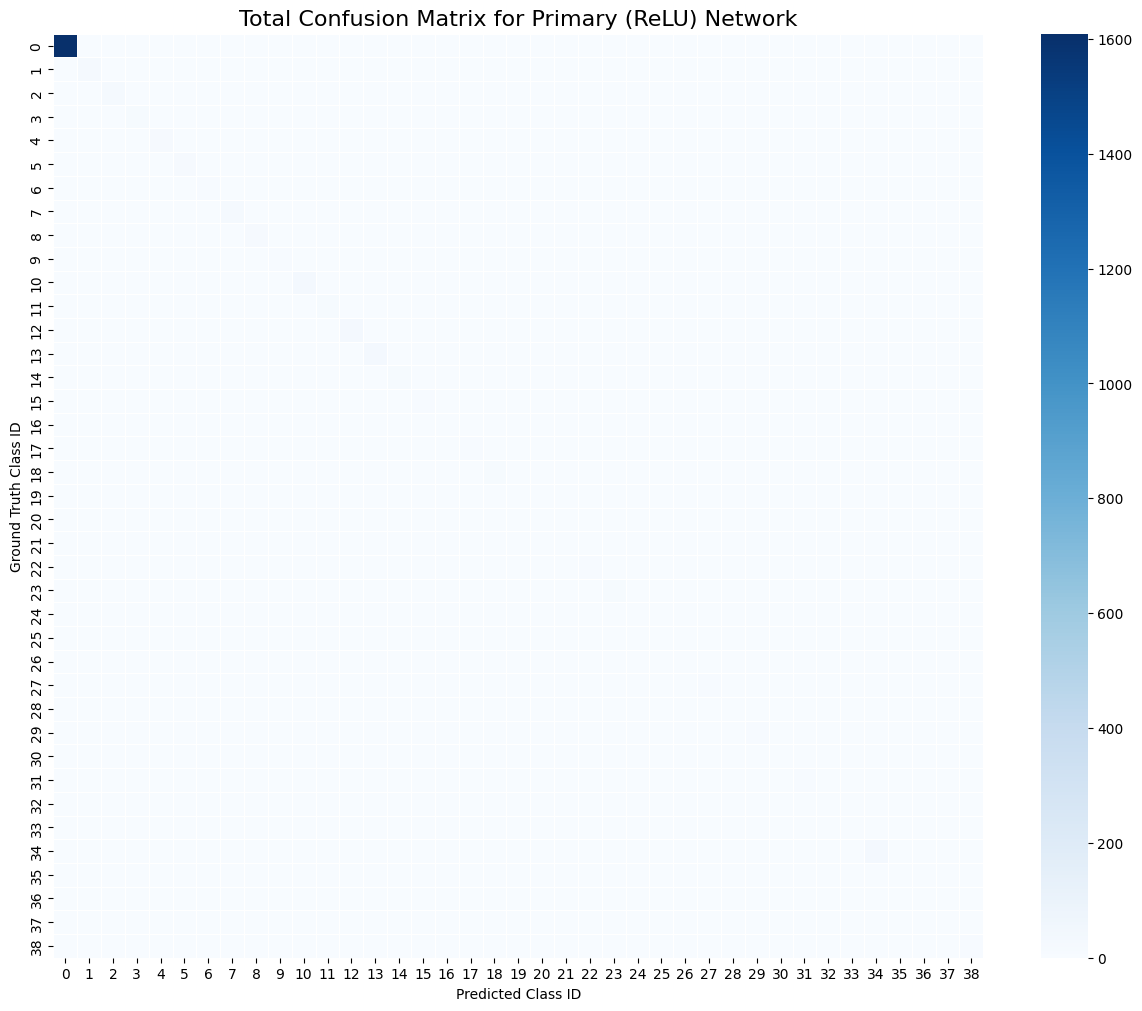

In [10]:
plt.figure(figsize=(15, 12))
cm = confusion_matrix(y_test_true, pred_relu)
sns.heatmap(cm, annot=False, cmap='Blues', linewidths=0.5)
plt.title('Total Confusion Matrix for Primary (ReLU) Network', fontsize=16)
plt.ylabel('Ground Truth Class ID')
plt.xlabel('Predicted Class ID')
plt.show()


### Real-world Random Inspections
A random qualitative test.


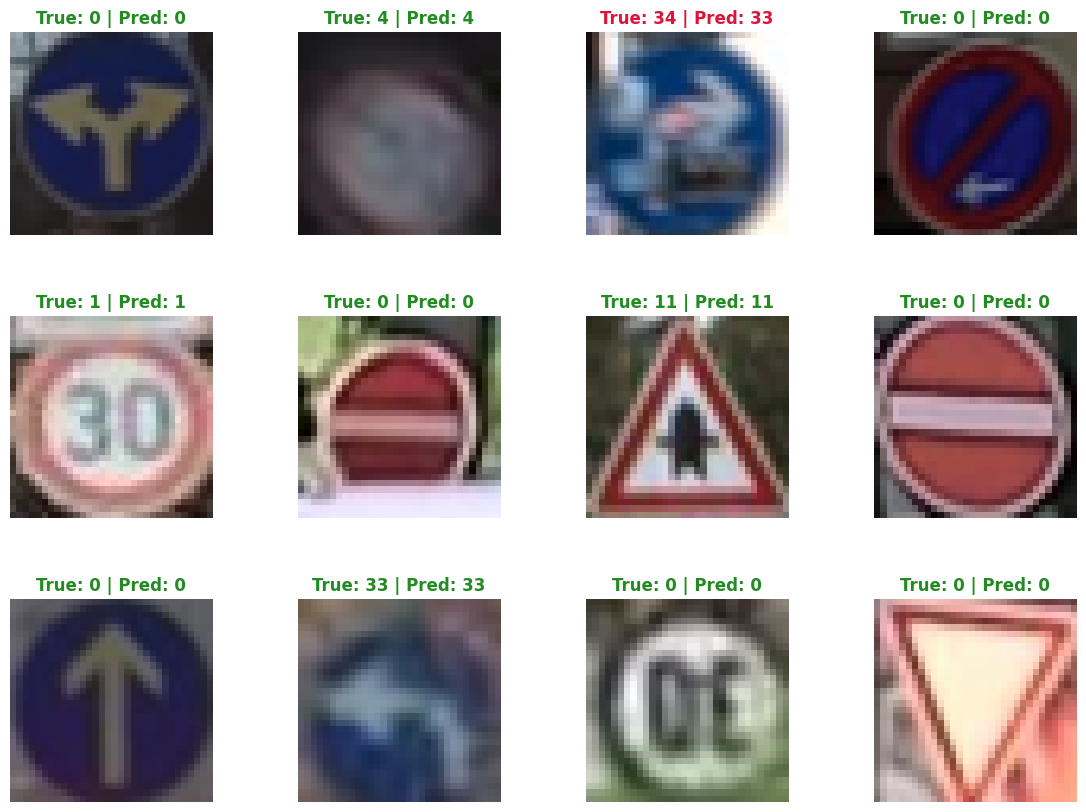

In [11]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.ravel()

# Randomly pick 12 indices from test set
for i in range(12):
    idx = random.randint(0, len(X_test) - 1)
    axes[i].imshow(X_test[idx])
    
    color = "forestgreen" if y_test_true[idx] == pred_relu[idx] else "crimson"
    axes[i].set_title(f"True: {y_test_true[idx]} | Pred: {pred_relu[idx]}", color=color, fontweight='bold')
    axes[i].axis('off')
    
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()


## 7. Committing Architecture and Bounds
Store the professionally crafted weights.


In [12]:
model_save_path = "gtsrb_production_model.h5"
model_relu.save(model_save_path)
print(f"Production pipeline model persisted successfully to {model_save_path}!")


Production pipeline model persisted successfully to gtsrb_production_model.h5!
